## Import libraries

In [1]:
import os
import time
import numpy as np
import tensorflow as tf
import kagglehub
import matplotlib.pyplot as plt
from datasets import load_from_disk
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, balanced_accuracy_score, classification_report

## Load and prepare data

In [2]:
# ==========================================
# STEP 1: LOAD AND PREPARE DATA
# ==========================================
print("Downloading and loading dataset...")
path = kagglehub.dataset_download("bocon66/processed-rice-244")
hf_dataset = load_from_disk(path)

# Extract class information safely
try:
    class_names = hf_dataset['train'].features['label'].names
except AttributeError:
    unique_labels = hf_dataset['train'].unique('label')
    class_names = [str(label) for label in sorted(unique_labels)]

num_classes = len(class_names)
print(f"Found {num_classes} classes: {class_names}")

# Create Label Encoder
label_encoder = tf.keras.layers.StringLookup(vocabulary=class_names, num_oov_indices=0)

BATCH_SIZE = 32
IMG_SIZE = (224, 224)

def preprocess_for_tf(image, label):
    image = tf.image.resize(image, IMG_SIZE)
    image = tf.cast(image, tf.float32)
    label = label_encoder(label)
    return image, label

print("Converting to TensorFlow datasets...")
train_dataset = hf_dataset["train"].to_tf_dataset(
    columns=["image"], label_cols=["label"], batch_size=BATCH_SIZE, shuffle=False # No shuffle needed for feature extraction
)
train_dataset = train_dataset.map(preprocess_for_tf, num_parallel_calls=tf.data.AUTOTUNE).prefetch(tf.data.AUTOTUNE)

validation_dataset = hf_dataset["validation"].to_tf_dataset(
    columns=["image"], label_cols=["label"], batch_size=BATCH_SIZE, shuffle=False
)
validation_dataset = validation_dataset.map(preprocess_for_tf, num_parallel_calls=tf.data.AUTOTUNE).prefetch(tf.data.AUTOTUNE)

100%|██████████| 3.41G/3.41G [01:29<00:00, 41.0MB/s]

Extracting files...


Found 21 classes: ['Bacterial Leaf Blight', 'Bakanae Disease', 'Blast', 'Brown Plant Hopper', 'Brown Spot', 'Chilo Stem Borer', 'False Smut', 'Healthy', 'Hispa', 'Leaf Scald', 'Narrow Brown Spot', 'Nitrogen Deficiency', 'Phosphorus Deficiency', 'Potassium Deficiency', 'Rice Gall Midge', 'Rice Leaf Folder', 'Rice Skipper', 'Sheath Blight', 'Thrips', 'Tungro Virus', 'Yellow Stem Borer']
Converting to TensorFlow datasets...


/usr/local/lib/python3.12/dist-packages/datasets/arrow_dataset.py:403: FutureWarning: The output of `to_tf_dataset` will change when a passing single element list for `labels` or `columns` in the next datasets version. To return a tuple structure rather than dict, pass a single string.
Old behaviour: columns=['a'], labels=['labels'] -> (tf.Tensor, tf.Tensor)  
             : columns='a', labels='labels' -> (tf.Tensor, tf.Tensor)  
New behaviour: columns=['a'],labels=['labels'] -> ({'a': tf.Tensor}, {'labels': tf.Tensor})  
             : columns='a', labels='labels' -> (tf.Tensor, tf.Tensor) 
  warnings.warn(


## Build ResNet50 Feature Extractor

In [3]:
# ==========================================
# STEP 2: BUILD RESNET50 FEATURE EXTRACTOR
# ==========================================
print("Building ResNet50 Feature Extractor...")
base_model = tf.keras.applications.ResNet50(input_shape=(224, 224, 3), include_top=False, weights='imagenet')
base_model.trainable = False

inputs = tf.keras.Input(shape=(224, 224, 3))
x = tf.keras.applications.resnet50.preprocess_input(inputs)
x = base_model(x, training=False)
outputs = tf.keras.layers.GlobalAveragePooling2D()(x)

# Note: We stop at the pooling layer. There is NO Dense layer here!
feature_extractor = tf.keras.Model(inputs, outputs)

Building ResNet50 Feature Extractor...
94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


## Extract features to Memory

In [4]:
# ==========================================
# STEP 3: EXTRACT FEATURES TO MEMORY
# ==========================================
# Scikit-Learn SVMs require data in memory as NumPy arrays (X_train, y_train)
def extract_features_and_labels(dataset, name="Dataset"):
    print(f"Extracting features from {name}...")
    features_list = []
    labels_list = []

    for images, labels in dataset:
        # Pass images through ResNet50 to get a 2048-number array per image
        features = feature_extractor.predict(images, verbose=0)
        features_list.append(features)
        labels_list.extend(labels.numpy())

    # Stack the lists into a single large NumPy matrix
    X = np.vstack(features_list)
    y = np.array(labels_list)
    return X, y

X_train, y_train = extract_features_and_labels(train_dataset, "Training Set")
X_val, y_val = extract_features_and_labels(validation_dataset, "Validation Set")

print(f"Extracted Training Shape: {X_train.shape}")
print(f"Extracted Validation Shape: {X_val.shape}")

Extracting features from Training Set...
Extracting features from Validation Set...
Extracted Training Shape: (26584, 2048)
Extracted Validation Shape: (5697, 2048)


## Train the SVM

In [5]:
# ==========================================
# STEP 4: TRAIN THE SVM
# ==========================================
print("Training the Support Vector Machine (SVM)...")

# We use kernel='rbf' (standard for non-linear data) and probability=True so we can output confidence %
svm_classifier = SVC(kernel='rbf', probability=True, random_state=42)

start_time = time.time()
svm_classifier.fit(X_train, y_train)
end_time = time.time()

svm_train_time_sec = end_time - start_time

Training the Support Vector Machine (SVM)...


## Evaluate, generate metrics

In [6]:
# ==========================================
# STEP 5: EVALUATE AND GENERATE METRICS
# ==========================================
print("Generating predictions on validation set...")

y_pred = svm_classifier.predict(X_val)

acc = accuracy_score(y_val, y_pred)
balanced_acc = balanced_accuracy_score(y_val, y_pred)
class_report_str = classification_report(y_val, y_pred, target_names=class_names)

print("\n" + "="*40)
print("FINAL SVM TRAINING REPORT")
print("="*40)
print(f"Total SVM Training Time: {svm_train_time_sec:.2f} seconds")
print(f"(Note: SVMs do not use Epochs)")
print("-" * 40)
print(f"Overall Accuracy:    {acc:.4f}")
print(f"Balanced Accuracy:   {balanced_acc:.4f}")
print("-" * 40)
print("Classification Report:")
print(class_report_str)

Generating predictions on validation set...

FINAL SVM TRAINING REPORT
Total SVM Training Time: 900.72 seconds
(Note: SVMs do not use Epochs)
----------------------------------------
Overall Accuracy:    0.9886
Balanced Accuracy:   0.9870
----------------------------------------
Classification Report:
                       precision    recall  f1-score   support

Bacterial Leaf Blight       1.00      1.00      1.00       442
      Bakanae Disease       1.00      1.00      1.00        15
                Blast       1.00      1.00      1.00       300
   Brown Plant Hopper       1.00      1.00      1.00        87
           Brown Spot       0.99      1.00      0.99       471
     Chilo Stem Borer       0.96      0.96      0.96       224
           False Smut       1.00      1.00      1.00        15
              Healthy       0.99      0.98      0.99       564
                Hispa       0.99      0.99      0.99       438
           Leaf Scald       0.99      0.98      0.99       501
   

## Test on an image

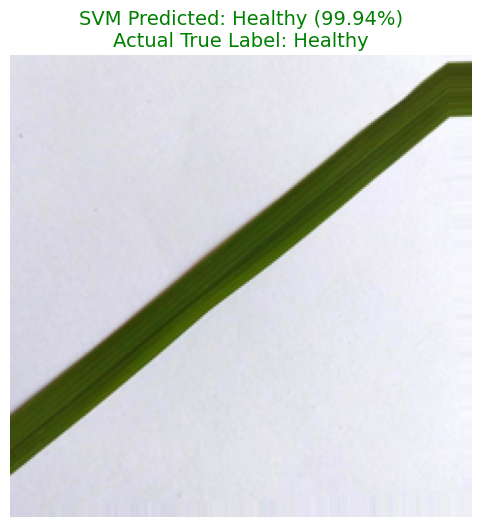

In [8]:
# ==========================================
# STEP 6: TEST ON A SINGLE IMAGE
# ==========================================
sample_index = 132
sample_example = hf_dataset['validation'][sample_index]

raw_image = sample_example['image']
true_label_text = sample_example['label']

# Preprocess image
img_tensor = tf.image.resize(raw_image, IMG_SIZE)
img_tensor = tf.cast(img_tensor, tf.float32)
img_batch = tf.expand_dims(img_tensor, 0)

# Extract feature using ResNet50 FIRST
extracted_feature = feature_extractor.predict(img_batch, verbose=0)

# Pass the feature to the SVM for final prediction
svm_prediction = svm_classifier.predict(extracted_feature)[0]
svm_probabilities = svm_classifier.predict_proba(extracted_feature)[0]

predicted_probability = np.max(svm_probabilities) * 100
predicted_class_name = class_names[svm_prediction]

# Display
plt.figure(figsize=(6, 6))
plt.imshow(raw_image)
plt.title(
    f"SVM Predicted: {predicted_class_name} ({predicted_probability:.2f}%)\n"
    f"Actual True Label: {true_label_text}",
    fontsize=14,
    color='green' if predicted_class_name == true_label_text else 'red'
)
plt.axis('off')
plt.show()